In [2]:
import cogsworth
import astropy.units as u
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from scipy.integrate import cumulative_trapezoid
from astropy.coordinates import SkyCoord
from scipy.ndimage import gaussian_filter
import seaborn as sns
import os

import sys
sys.path.append('../src')
import plotting, helpers
from importlib import reload

%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [3]:
files = ["fiducial"]
labels = ["Fiducial"]
colours = ["tab:blue"]

In [4]:
pops, data = helpers.load_postprocessed_pops(
    [f"/mnt/ceph/users/twagg/underworld/postprocessed/{file}" for file in files],
    labels, colours
)

In [5]:
pop = pops[0]

# Rates

In [6]:
scale_up = 6e10 / data["Fiducial"]["mass_binaries"]
scale_up

np.float64(550.3035750957637)

In [7]:
n_ns = len(data["Fiducial"]["mass"]["NS"])
n_bh = len(data["Fiducial"]["mass"]["BH"])
print(f"Rates (unscaled)\n  Total: {n_ns + n_bh}, NSs: {n_ns}, BHs: {n_bh}")
print(f"Rates (scaled)\n  Total: {(n_ns + n_bh) * scale_up:.1e}, NSs: {n_ns * scale_up:.1e}, BHs: {n_bh * scale_up:.1e}")

Rates (unscaled)
  Total: 1224488, NSs: 884829, BHs: 339659
Rates (scaled)
  Total: 6.7e+08, NSs: 4.9e+08, BHs: 1.9e+08


Olejak+20 predicted 1.2e8 BHs, close!

# Spatial distributions

In [ ]:
if os.path.exists("/mnt/ceph/users/twagg/underworld/stars_sfh.h5"):
    stars = cogsworth.sfh.load("/mnt/ceph/users/twagg/underworld/stars_sfh.h5")
else:
    stars = cogsworth.sfh.SandersBinney2015(
        size=(n_bh + n_ns),
        **{
            "potential": gp.MilkyWayPotential(version='v2'),
            "time_bins": 5,
            "verbose": True
        }
    )
    stars.save("/mnt/ceph/users/twagg/underworld/stars_sfh")

### 2D density plot

{'norm': <matplotlib.colors.LogNorm object at 0x152b4b7323d0>}
{'norm': <matplotlib.colors.LogNorm object at 0x152b4ff02690>}


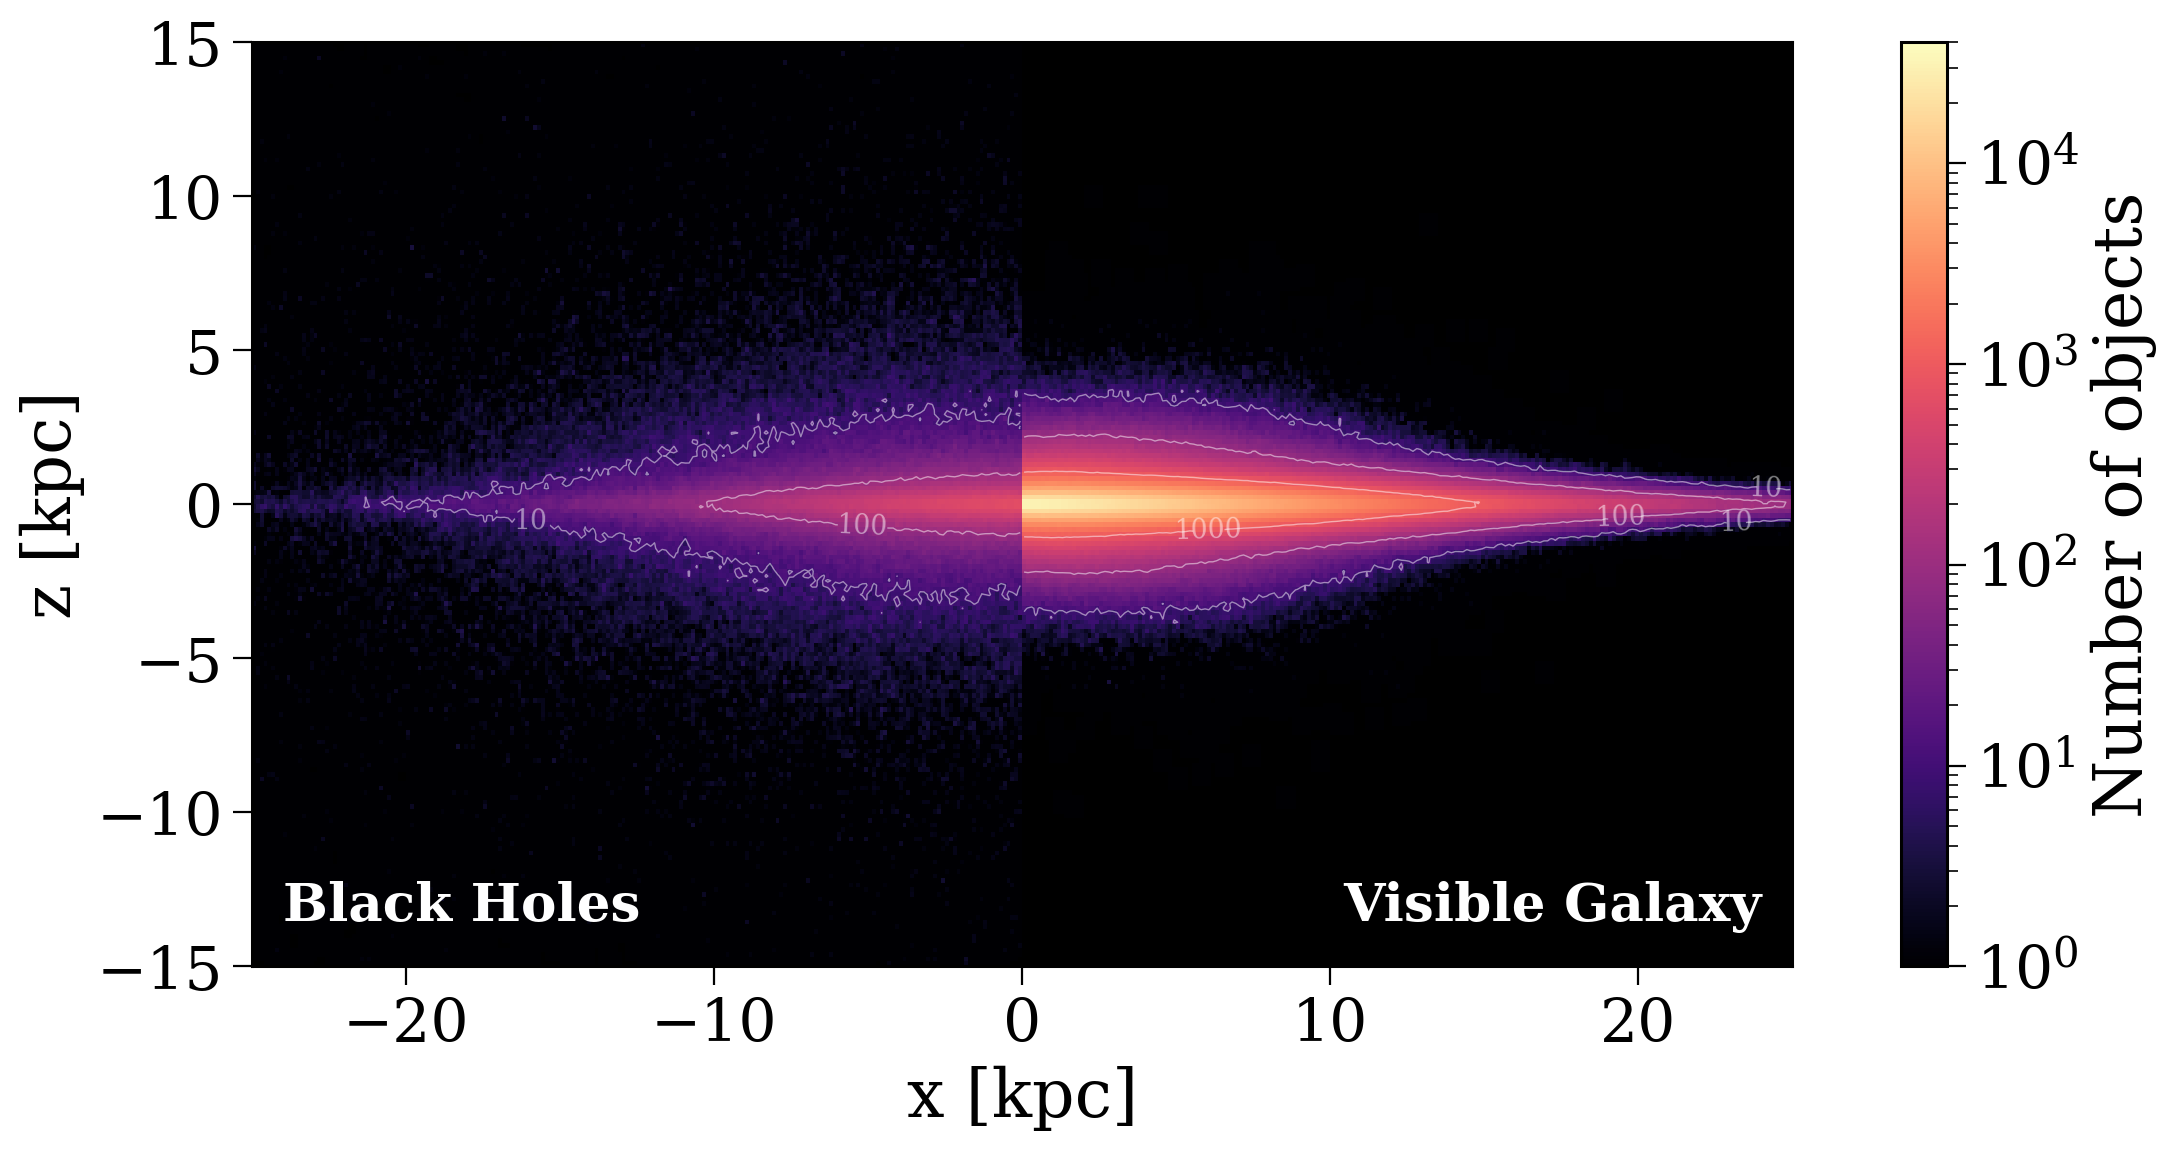

In [9]:
reload(plotting)
fig, ax = plotting.plot_side_on_density(
    xs=[stars.x, data["Fiducial"]["pos"]["BH"][:, 0]],
    zs=[stars.z, data["Fiducial"]["pos"]["BH"][:, 2]],
    labels=["Black Holes", "Visible Galaxy"],
    xlim=25,
    zlim=15,
    n_bins=200,
    sigma=0.5,
    contours=[10, 100, 1000],
    apply_smoothing=True,
    show=False,
    norm="log",
)

# plt.savefig("../plots/density_stars_vs_blackholes.pdf", format="pdf", bbox_inches='tight')
plt.show()

0.029166399732492895


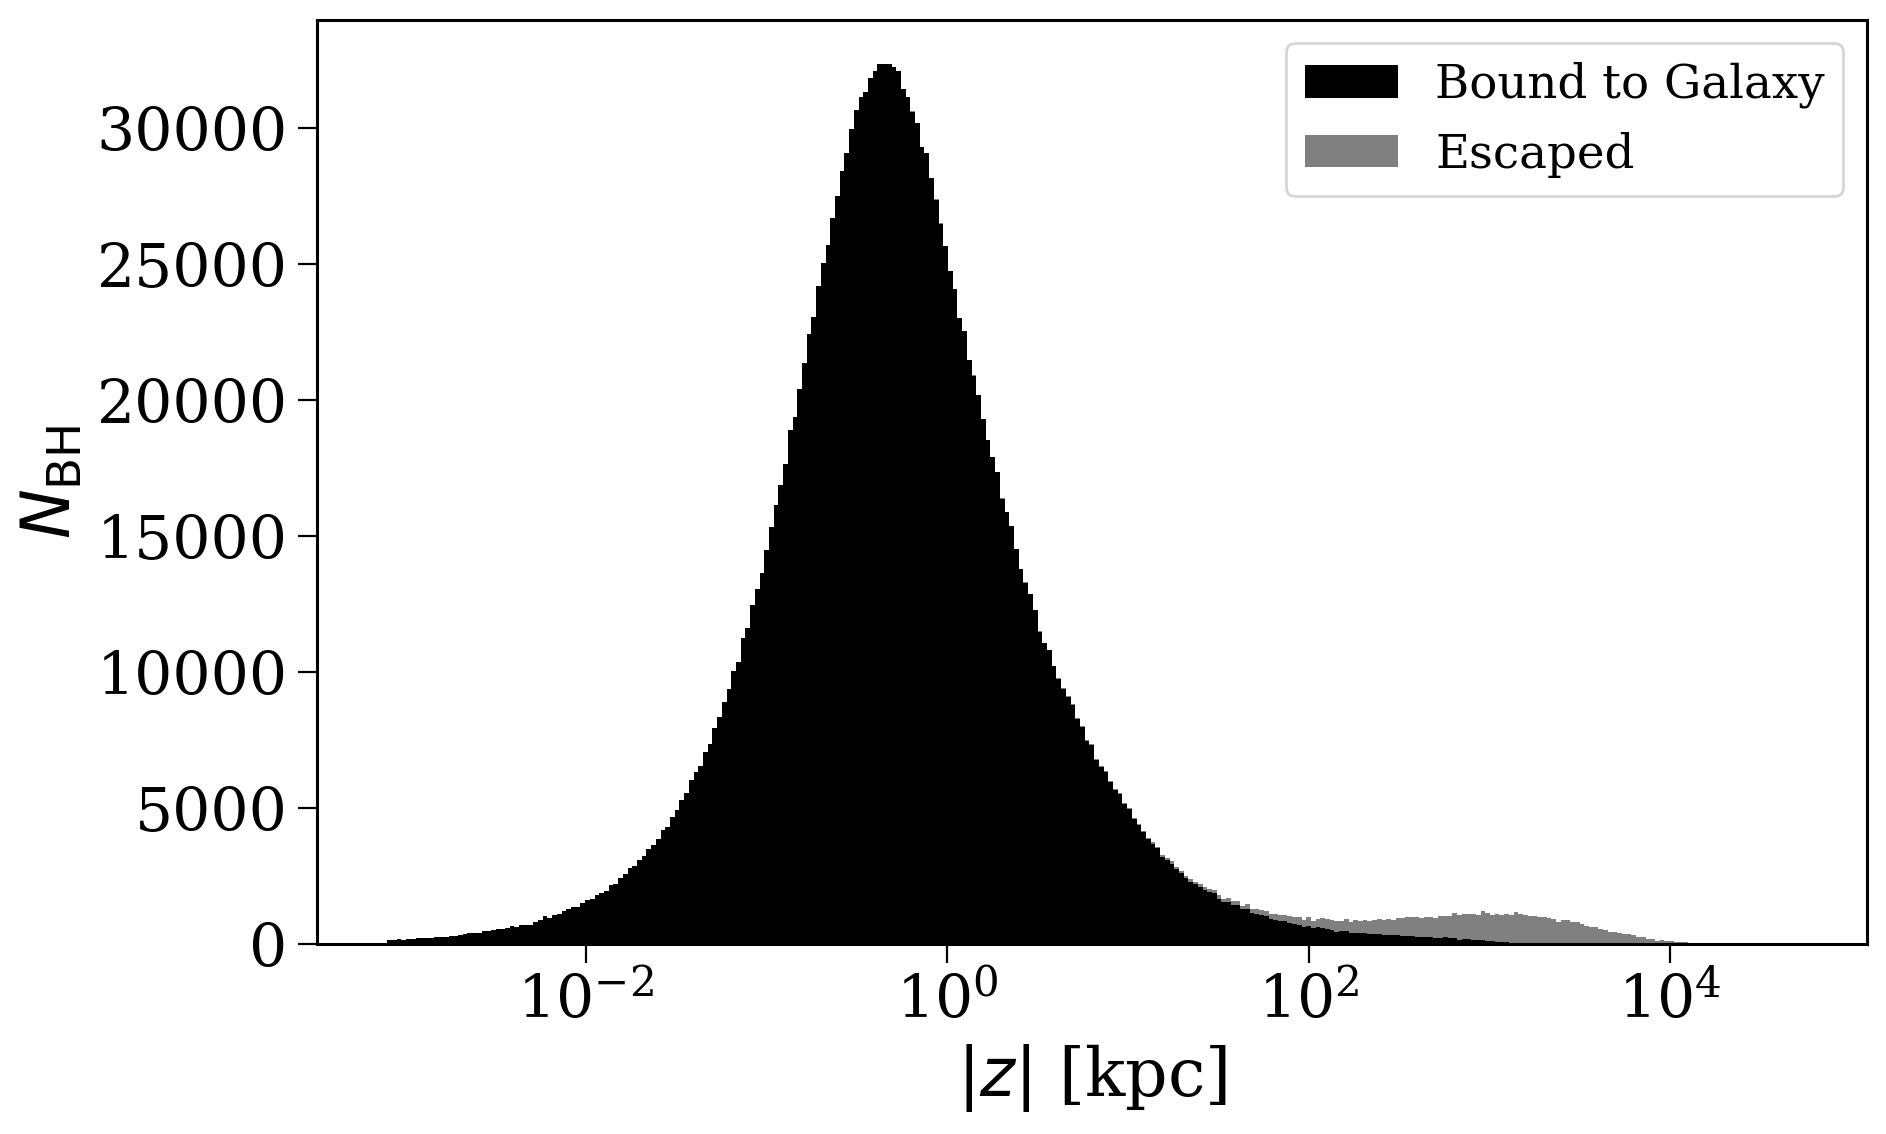

In [69]:
fig, ax = plt.subplots(figsize=(10, 6))

co_pos = data[pop.label]["pos"]["BH"]
co_vel = data[pop.label]["vel"]["BH"]
mask = data[pop.label]["escaped"]["BH"]

abs_z = np.abs(co_pos[:, 2])

print(mask.sum() / len(mask))

ax.hist([abs_z[~mask], abs_z[mask]], bins=np.geomspace(8e-4, 5e4, 300), stacked=True,
        color=['black', 'grey'], label=['Bound to Galaxy', 'Escaped'])

# ax.hist(np.abs(co_pos[:, 2].to(u.kpc).value)[mask], bins=bins, histtype='step', lw=2, color=pop.colour)
# ax.hist(np.abs(co_pos[:, 2].to(u.kpc).value)[mask], bins=bins, alpha=0.4, color=pop.colour,
#         label=f'{pop.label} (N={len(co_pos[mask])})')

ax.set(
    xscale="log",
    xlabel=r'$|z|$ [kpc]',
    ylabel=r'$N_{\rm BH}$',
)
ax.legend(title=None)
plt.show()

In [70]:
(abs_z < 10).sum() / len(abs_z)

np.float64(0.9241052757130528)

[ 1.97599136  7.03491798 12.21739054 13.57979687]
[ 6.18273437 24.84599414]


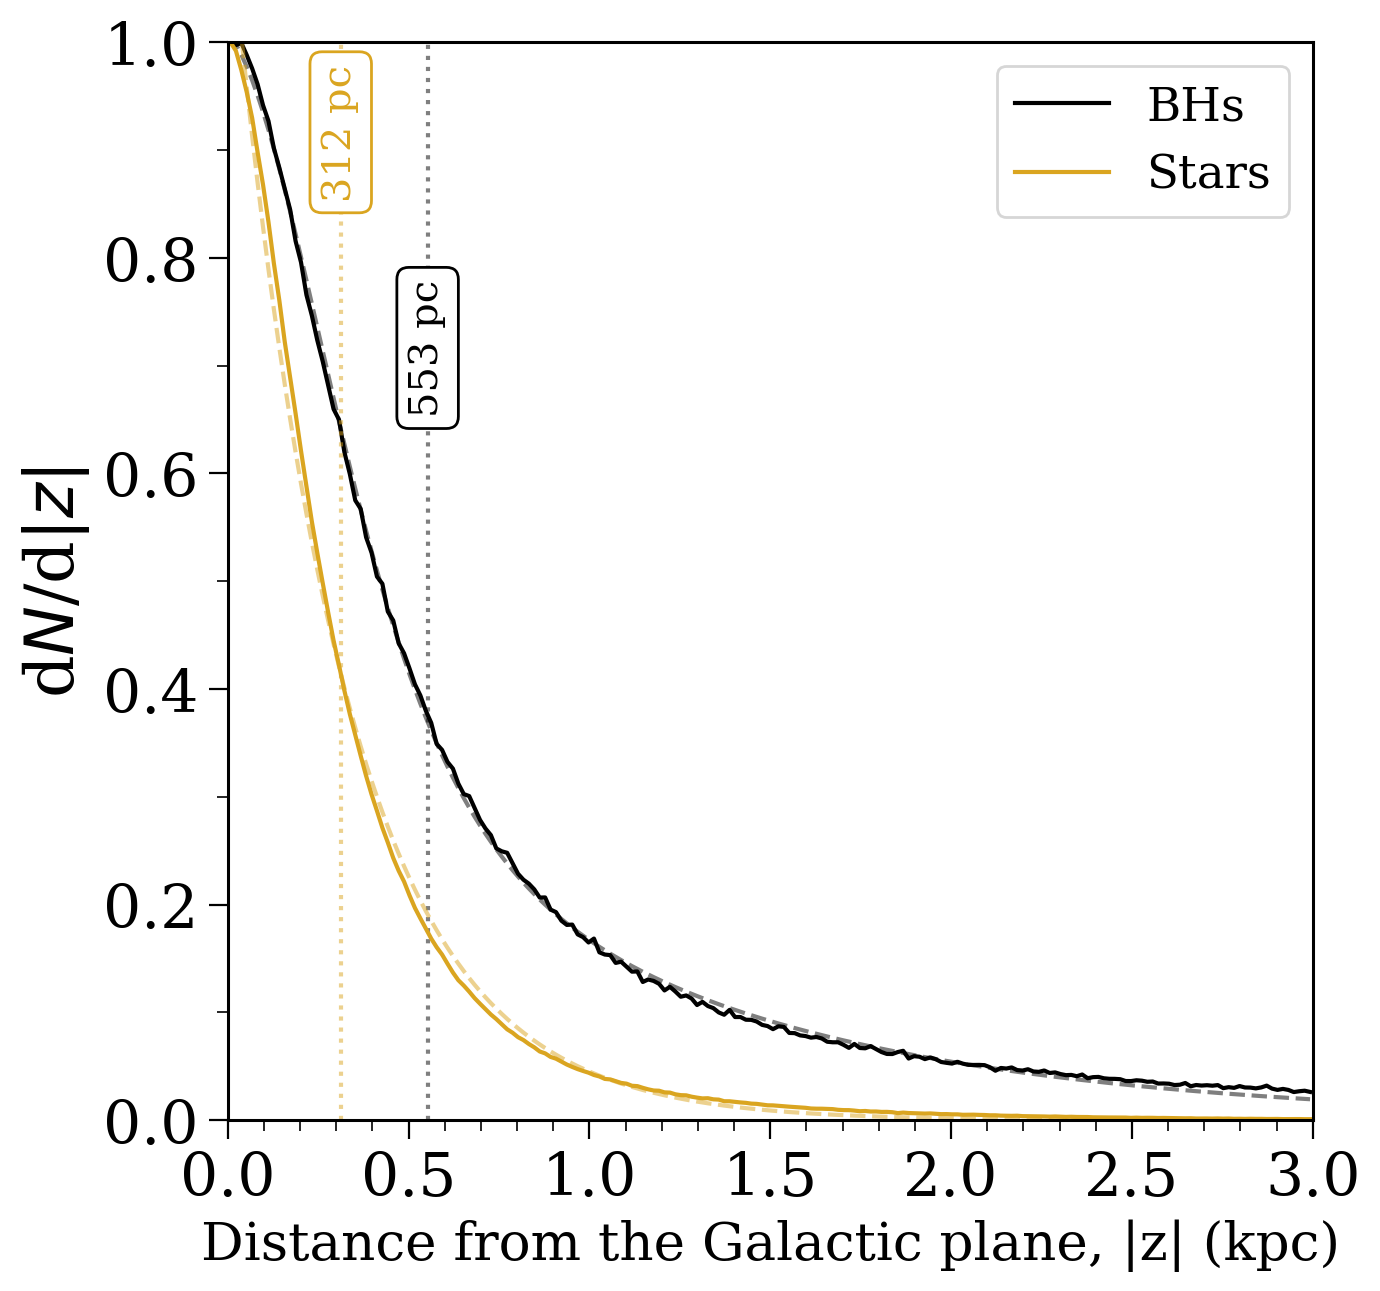

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

for z, R, label, colour in zip(
    [data["Fiducial"]["pos"]["BH"][:, 2], stars.z],
    [np.linalg.norm(data["Fiducial"]["pos"]["BH"][:, :2], axis=1), stars.rho],
    ["BHs", "Stars"],
    ["black", "goldenrod"]
):

    scale_height, _, _ = plotting.estimate_scale_height(
        z=z,
        plot=True,
        label=label,
        colour=colour,
        show=False,
        fig=fig,
        ax=ax,
        bins=np.linspace(0, 3, 201),
        xlim=(0, 3),
        ylim=(0, 1),
        n_components=2 if label.startswith("BH") else 1,
        scale_height_locs=[0.78 if label.startswith("BH") else 0.98, 0.22],
        R=None,
    )

# add minor ticks every 0.1 kpc
ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

# plt.savefig("../plots/scale_height_blackholes_vs_stars.pdf", format="pdf", bbox_inches='tight')
plt.show()

## Compare to Sweeney scale heights

In [72]:
sweeney = pd.read_csv("~/ceph/underworld/sweeney_data/kicked_remnants_igoshev_young_7.8_DC_integrated_final.csv")

[ 1.97599136  7.03491798 12.21739054 13.57979687]
73571 objects before Rlims
2283 objects in Rlims
[18.16329172 27.84662695]
[ 5.03037564 22.5967358  31.99278427 24.565371  ]


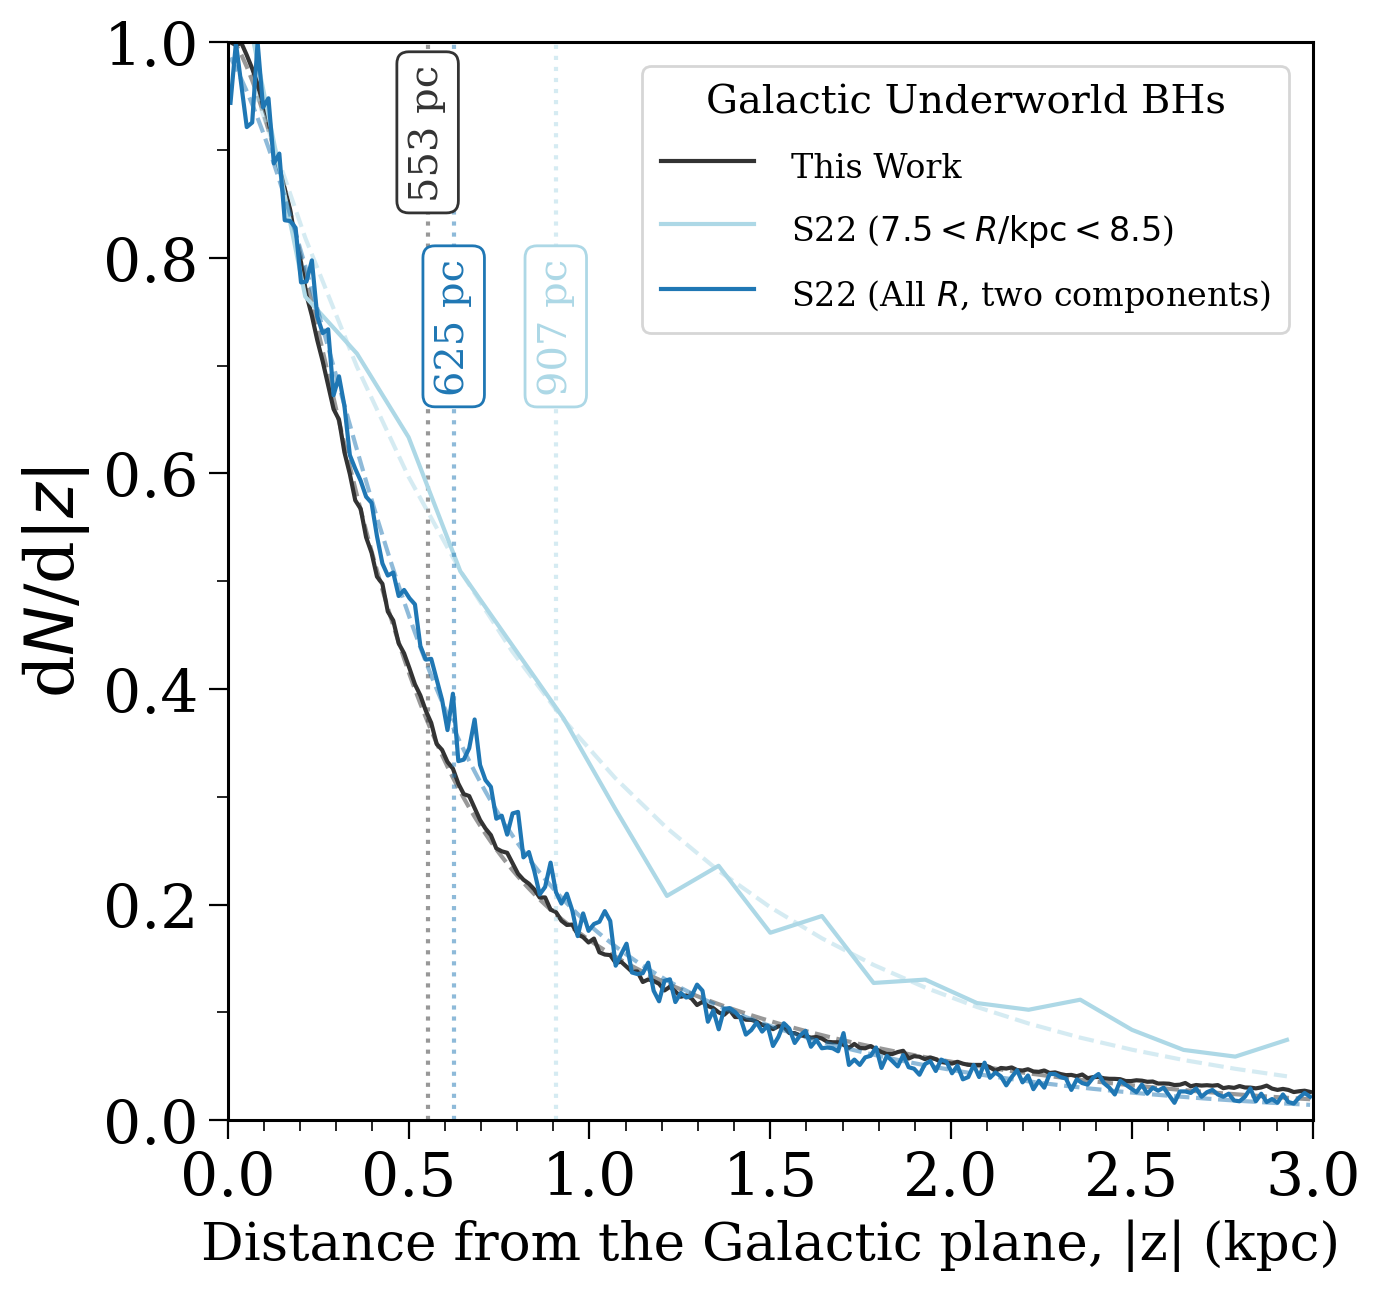

In [73]:
reload(plotting)

sweeney_bhs = sweeney[(sweeney["rtype"] == "Black Hole") & ~sweeney["will_escape"]]

fig, ax = plt.subplots(figsize=(7, 7))

plotting.estimate_scale_height(
    z=data["Fiducial"]["pos"]["BH"][:, 2],
    plot=True,
    label=r"This Work",
    colour="#333",
    fig=fig,
    ax=ax,
    show=False,
    bins=np.linspace(0, 3, 201),
    xlim=(0, 3),
    ylim=(0, 1),
    scale_height_locs=[0.98],
    n_components=2,
)

# plotting.estimate_scale_height(
#     z=kinematics["Fiducial"]["pos"]["BH"][:, 2],
#     R=np.linalg.norm(kinematics["Fiducial"]["pos"]["BH"][:, :2], axis=1),
#     plot=True,
#     label=r"This Work",
#     colour="#999",
#     fig=fig,
#     ax=ax,
#     show=False,
#     bins=np.linspace(0, 3, 201),
#     xlim=(0, 3),
#     ylim=(0, 1),
#     scale_height_locs=[0.2],
#     n_components=2,
# )

plotting.estimate_scale_height(
    z=sweeney_bhs["pz"].values * u.kpc,
    R= sweeney_bhs["R"].values * u.kpc,
    plot=True,
    label=r"S22 ($7.5 < R / {\rm kpc} < 8.5$)",
    colour="lightblue",
    fig=fig,
    ax=ax,
    show=False,
    bins="auto",
    xlim=(0, 3),
    ylim=(0, 1),
    n_components=1,
    scale_height_locs=[0.8],
)

plotting.estimate_scale_height(
    z=sweeney_bhs["pz"].values * u.kpc,
    plot=True,
    label=r"S22 (All $R$, two components)",
    colour="tab:blue",
    fig=fig,
    ax=ax,
    show=False,
    bins=np.linspace(0, 3, 201),
    xlim=(0, 3),
    ylim=(0, 1),
    n_components=2,
    scale_height_locs=[0.8],
)

leg = ax.get_legend()
leg.set_title("Galactic Underworld BHs", prop={'size': 0.6 * fs})
for text in leg.get_texts():
    text.set_fontsize(0.5 * fs)

ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

plt.savefig("../plots/scale_height_sweeney.pdf", format="pdf", bbox_inches='tight')
plt.show()

# Mass distribution

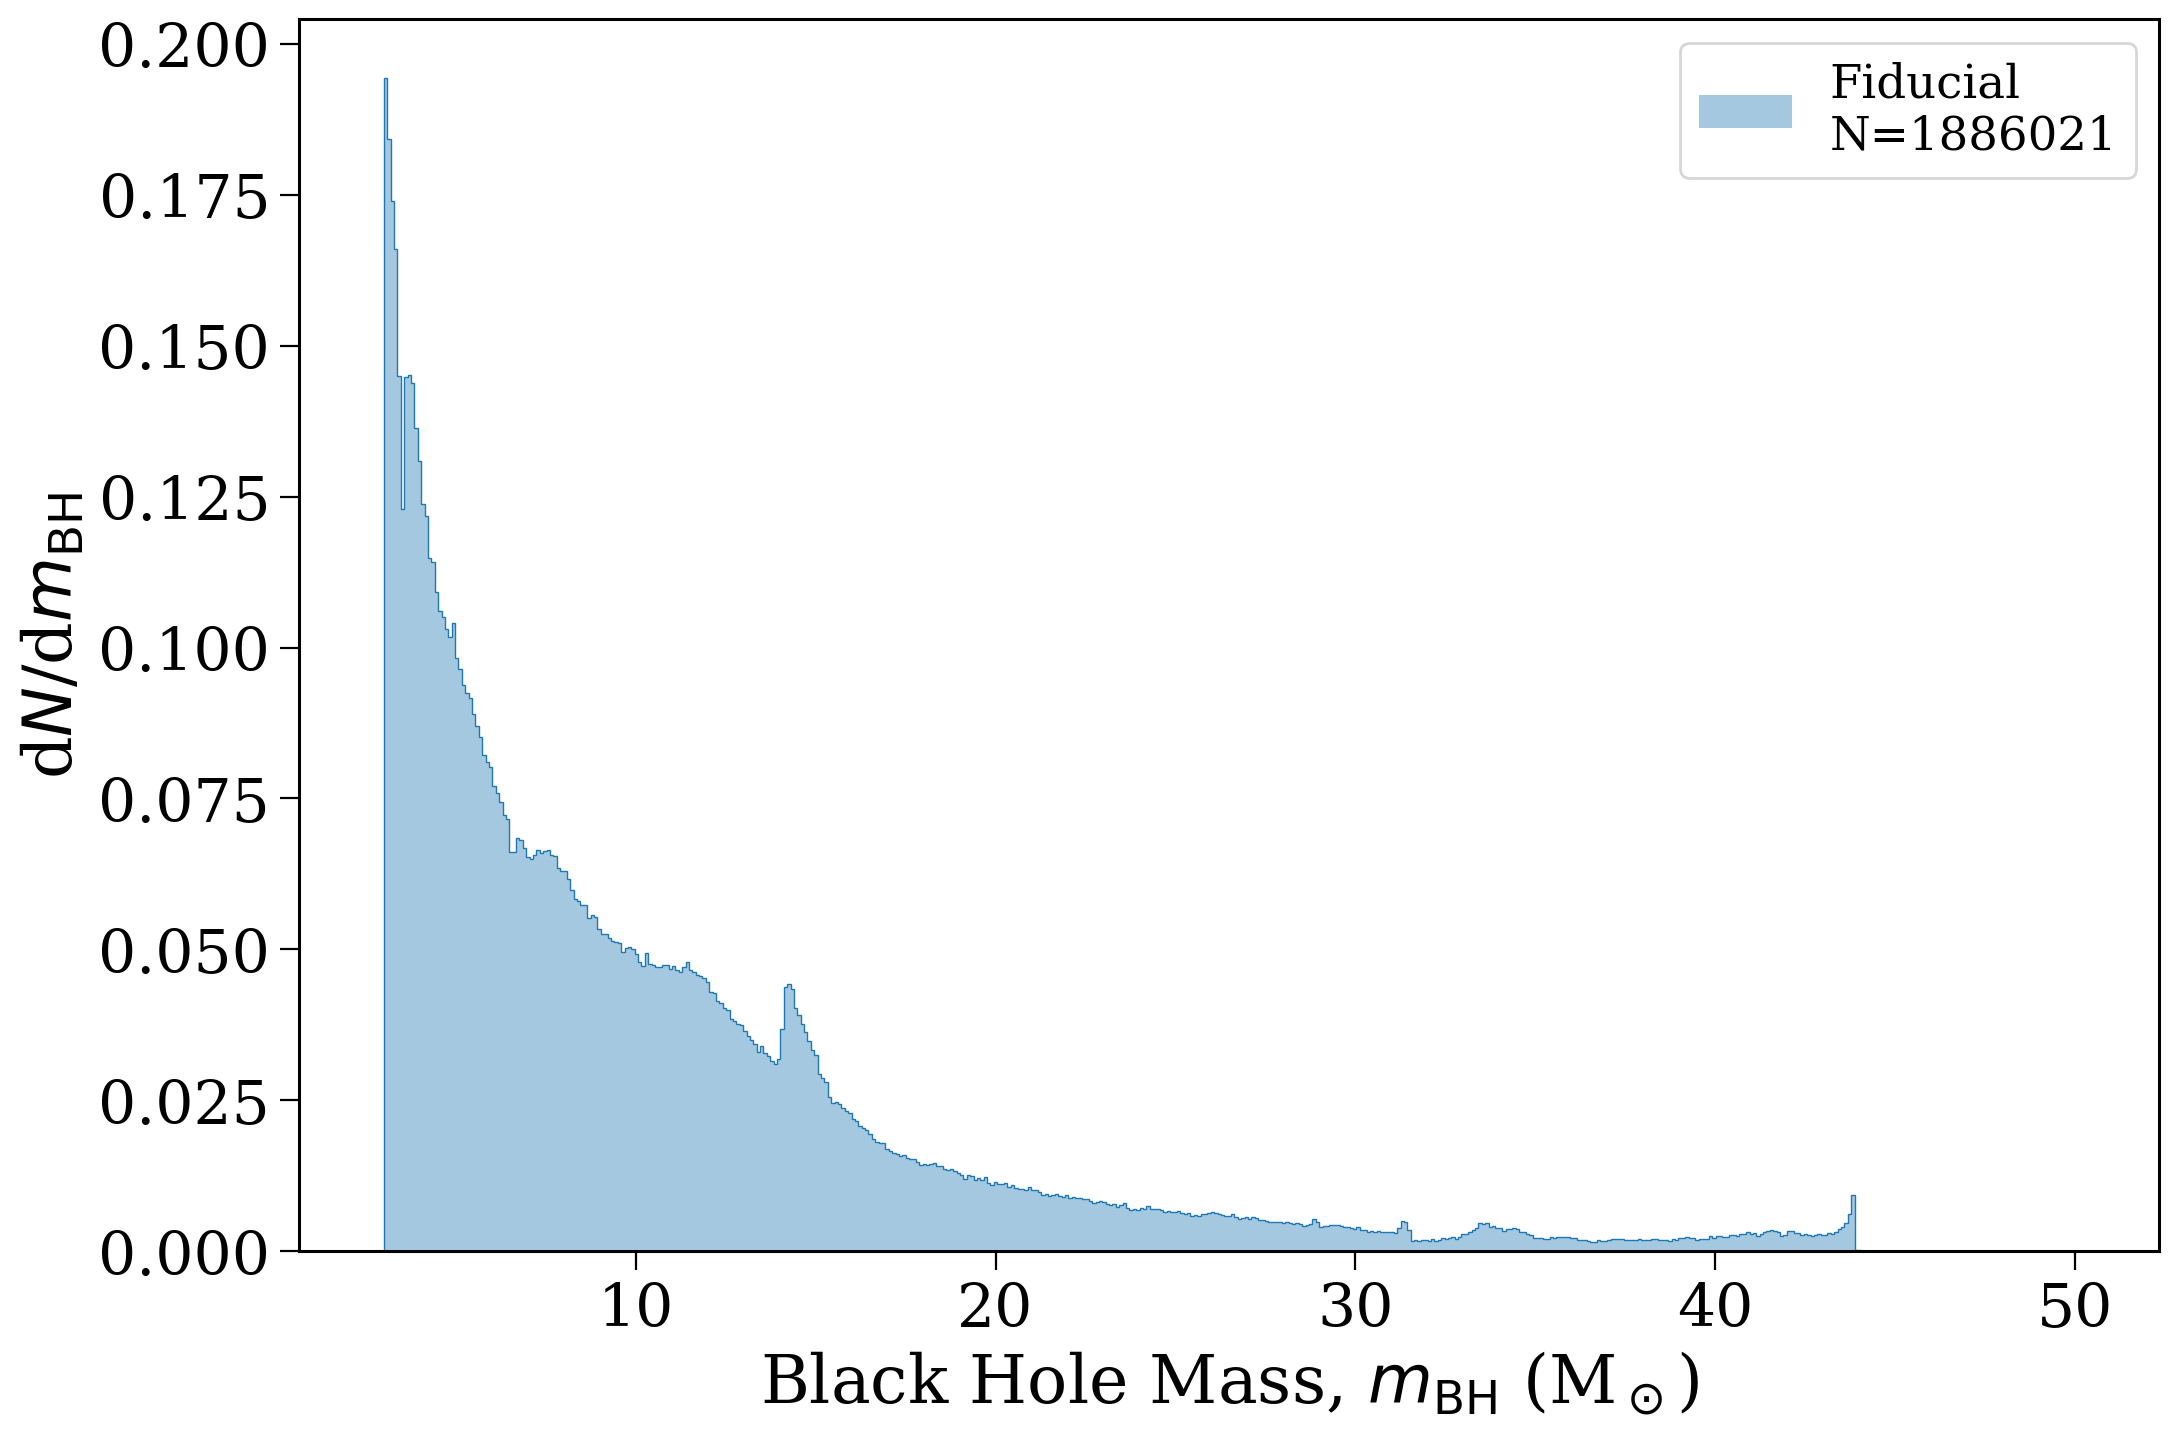

In [49]:
reload(plotting)
fig, ax = plotting.compare_table_quantity(
    pops=[pop],
    quantity="mass",
    kstar=14,
    bins=np.linspace(3, 50, 500),
    xlabel=r"Black Hole Mass, $m_{\rm BH}$ (M$_\odot$)",
    ylabel=r"d$N$/d$m_{\rm BH}$",
    show=False,
    lw=0.5
)
plt.savefig("../plots/bh_mass_distribution.pdf", format="pdf", bbox_inches='tight')
plt.show()

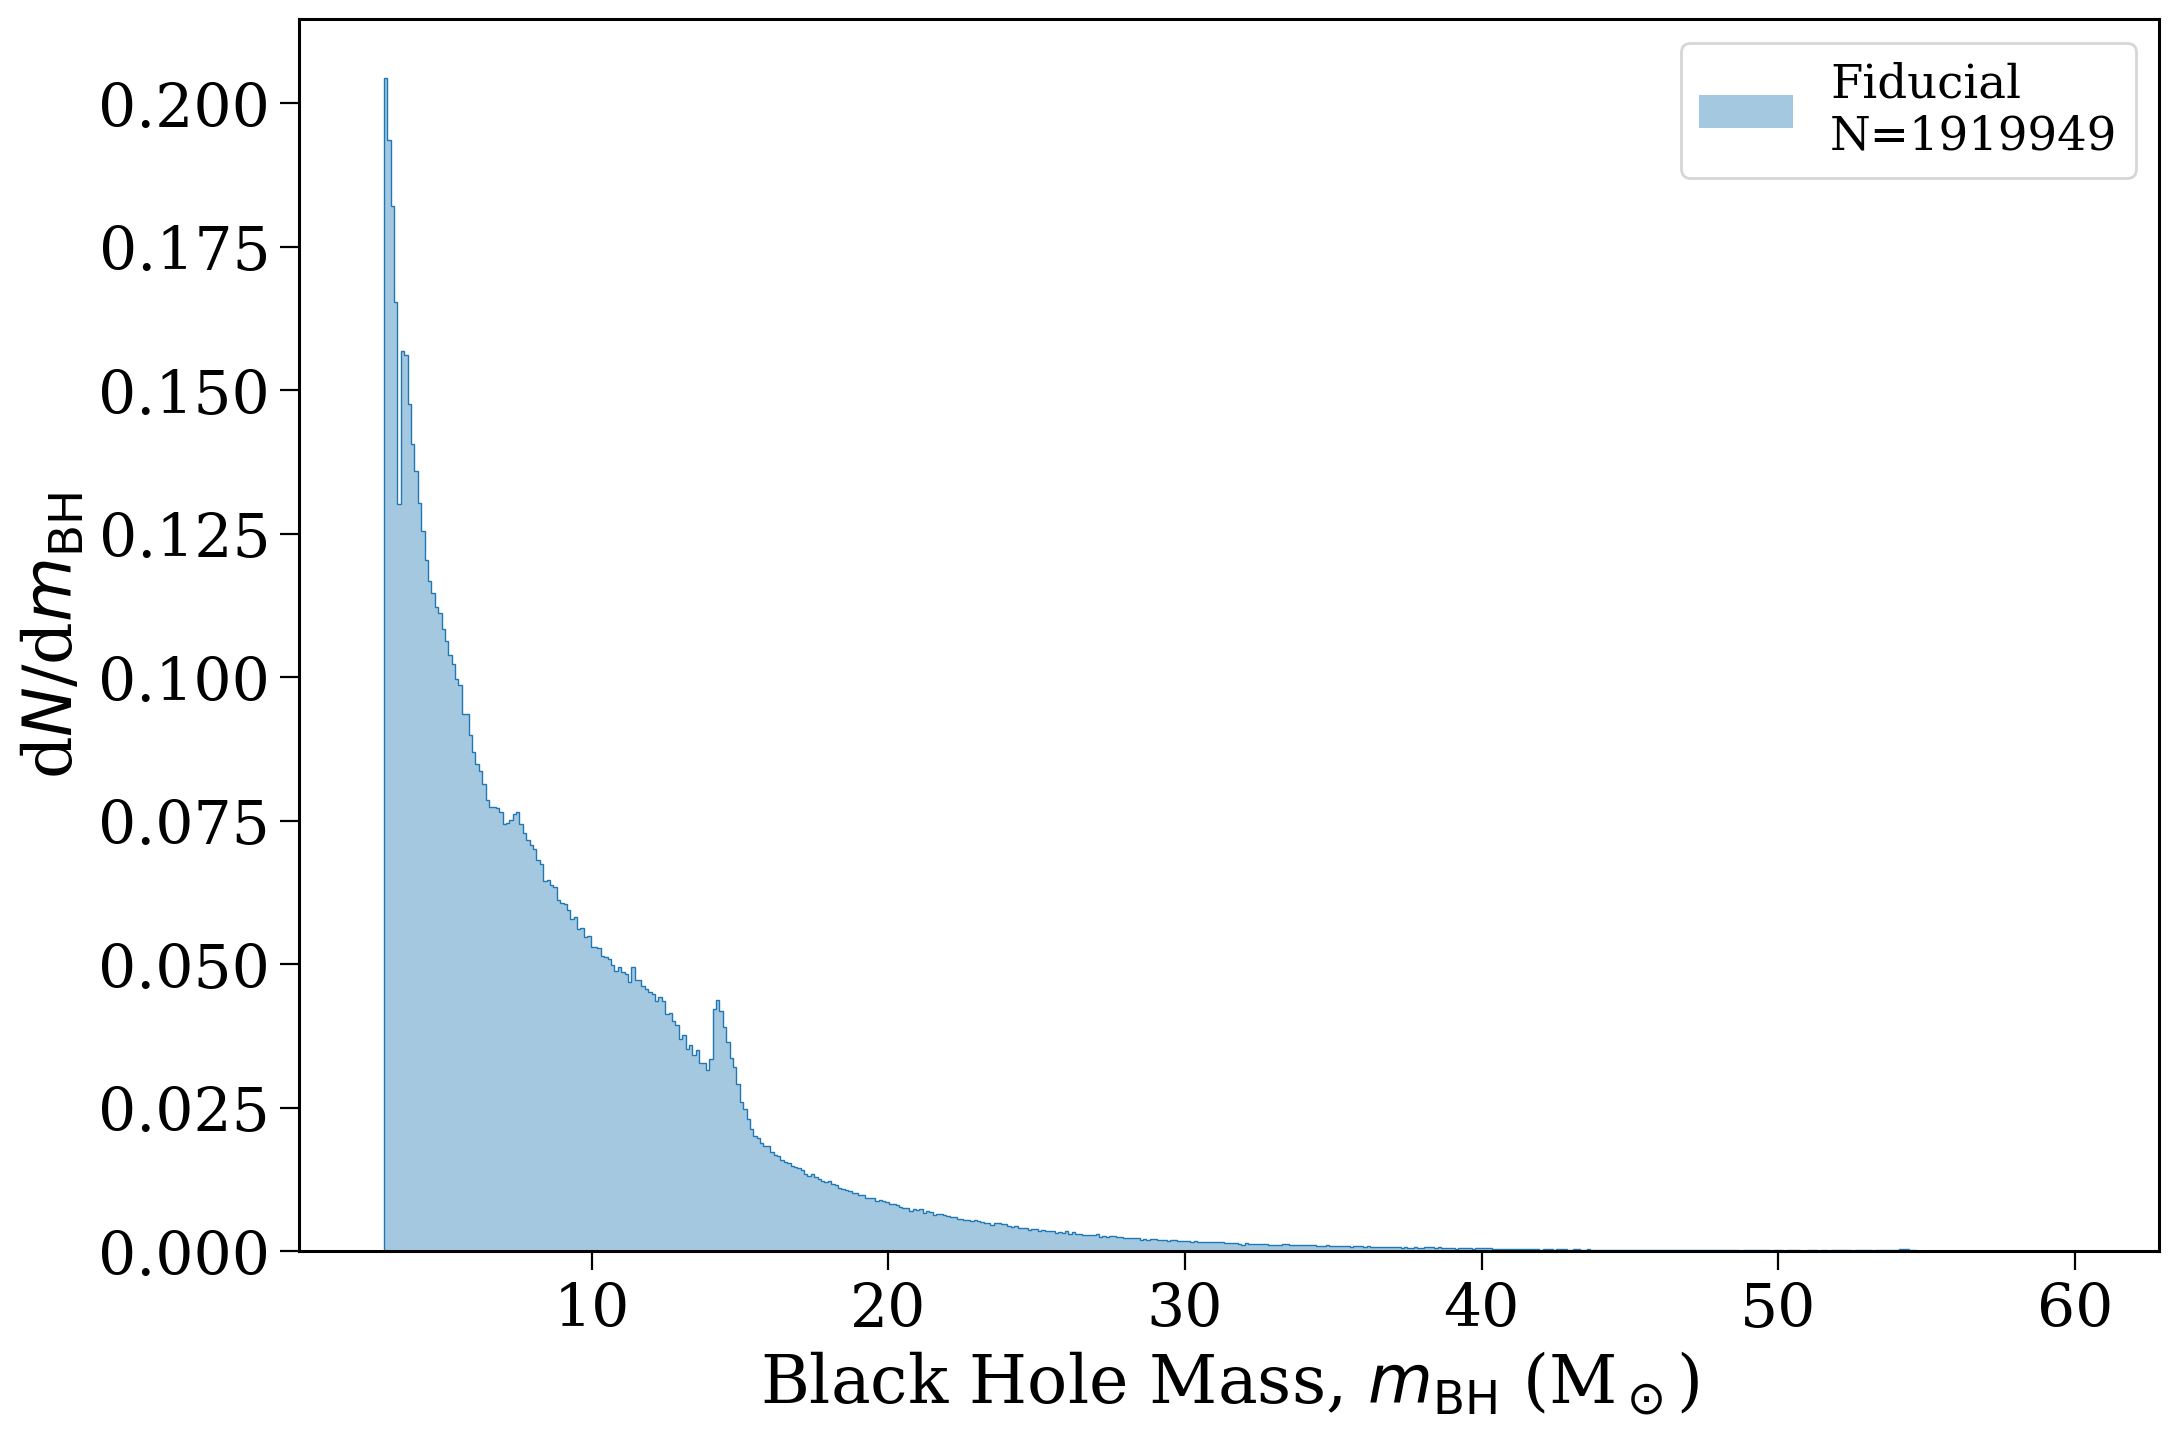

In [74]:
reload(plotting)
fig, ax = plotting.compare_table_quantity(
    pops=[pop],
    quantity="mass",
    kstar=14,
    bins=np.linspace(3, 60, 500),
    xlabel=r"Black Hole Mass, $m_{\rm BH}$ (M$_\odot$)",
    ylabel=r"d$N$/d$m_{\rm BH}$",
    show=False,
    lw=0.5
)
# plt.savefig("../plots/bh_mass_distribution.pdf", format="pdf", bbox_inches='tight')
plt.show()

# Spatial vs. Mass

Larger mass objects (particularly BHs) are going to get different kicks, we should see that show up in their distribution

### Average mass trends

In [76]:
data["Fiducial"]["init_z"]

{'NS': array([ 0.14059118, -0.08110006, -0.28809262, ...,  0.1173912 ,
         0.58496278, -0.38785132], shape=(5007743,)),
 'BH': array([-0.2411425 , -0.22865598,  0.48623553, ..., -0.78807683,
        -0.08235044, -0.64449231], shape=(1919949,)),
 'CO': array([ 0.14059118, -0.08110006, -0.28809262, ..., -0.78807683,
        -0.08235044, -0.64449231], shape=(6927692,))}

In [91]:
z_range = np.geomspace(0.1, 10, 1000)

mean_masses = helpers.get_average_mass_at_z(
    abs_zs=[np.abs(data["Fiducial"]["pos"]["BH"][:, 2]),
            np.abs(data["Fiducial"]["init_z"]["BH"])],
    bh_masses=[data["Fiducial"]["mass"]["BH"], data["Fiducial"]["mass"]["BH"]],
    z_range=z_range,
    window_width=0.1
)

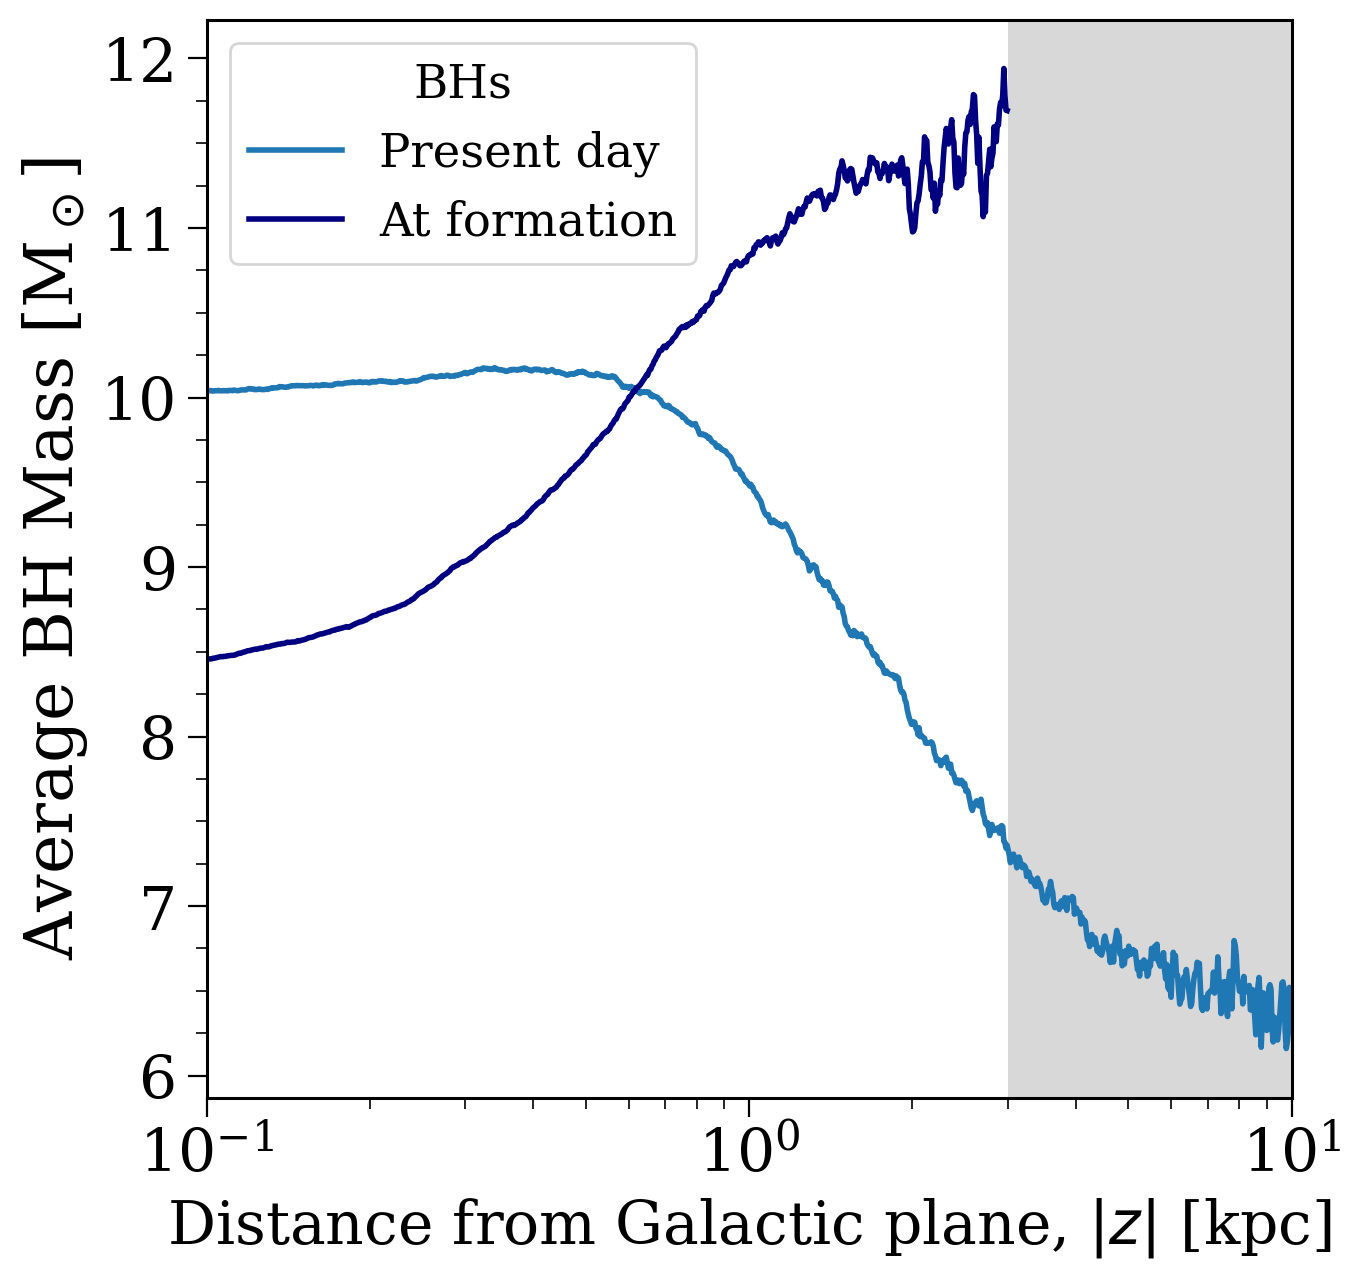

(<Figure size 700x700 with 1 Axes>,
 <Axes: xlabel='Distance from Galactic plane, $|z|$ [kpc]', ylabel='Average BH Mass [M$_\\odot$]'>)

In [94]:
plotting.plot_avg_mass_vs_z(
    mean_masses, ["Present day", "At formation"], ["tab:blue", "navy"], [10, 3], z_range,
    save="../plots/average_bh_mass_vs_z.pdf"
)

### Why is formation opposite?
Metallicity!

In [79]:
z_range = np.geomspace(0.1, 3, 100)
mean_Z = helpers.get_average_mass_at_z([abs(stars.z.value)], [stars.Z.value], z_range=z_range)

Text(0.5, 0, 'Distance from Galactic plane, $|z|$ [kpc]')

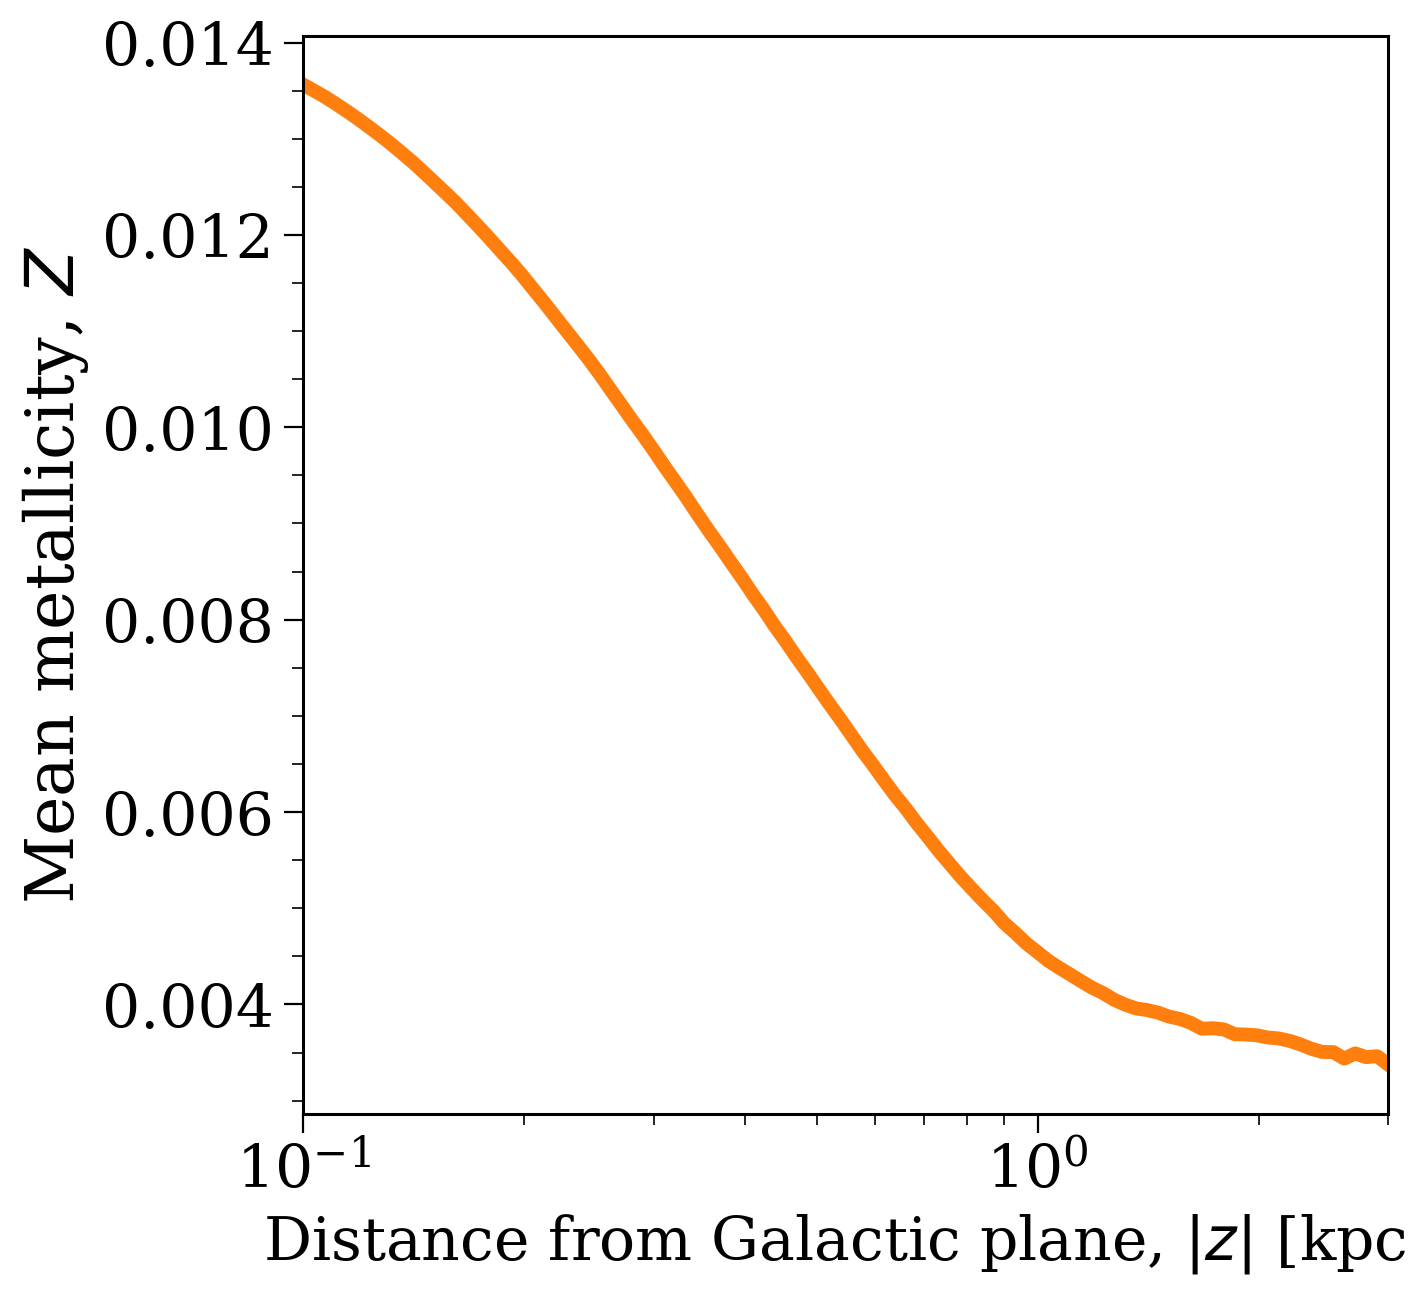

In [80]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.plot(z_range, mean_Z[0], lw=5, label="Mean Stellar Mass", color="tab:orange")
ax.set(
    xscale="log",
    xlabel=r'Distance from Galactic plane, $|z|$ [kpc]',
    ylabel='Mean metallicity, $Z$',
    xlim=(z_range.min(), z_range.max()),
)

ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.0005))
ax.set_xlabel(ax.get_xlabel(), fontsize=0.9*fs)

## Stats

In [81]:
# average_escaped_BH_mass = np.mean(masses["BH"][kinematics[pop.label]["escaped"]["BH"]])
# average_bound_BH_mass = np.mean(masses["BH"][~kinematics[pop.label]["escaped"]["BH"]])

average_escaped_BH_mass = np.mean(data["Fiducial"]["mass"]["BH"][data["Fiducial"]["escaped"]["BH"]])
average_bound_BH_mass = np.mean(data["Fiducial"]["mass"]["BH"][~data["Fiducial"]["escaped"]["BH"]])

In [82]:
avg_bound_BH_close_to_disc = np.mean(data["Fiducial"]["mass"]["BH"][( 
    ~data["Fiducial"]["escaped"]["BH"] &
    (abs(data["Fiducial"]["pos"]["BH"][:, 2]) < 1)
)])

avg_bound_BH_far_from_disc = np.mean(data["Fiducial"]["mass"]["BH"][( 
    ~data["Fiducial"]["escaped"]["BH"] &
    (abs(data["Fiducial"]["pos"]["BH"][:, 2]) >= 1)
)])

In [84]:
print("Average BH masses:")
print(f"  Escaped: {average_escaped_BH_mass:.1f} Msun")
print(f"  Bound:   {average_bound_BH_mass:.1f} Msun")
print(f"    Close to disc (<1 kpc):  {avg_bound_BH_close_to_disc:.1f} Msun")
print(f"    Far from disc (>=1 kpc): {avg_bound_BH_far_from_disc:.1f} Msun")

Average BH masses:
  Escaped: 5.2 Msun
  Bound:   9.3 Msun
    Close to disc (<1 kpc):  10.0 Msun
    Far from disc (>=1 kpc): 7.7 Msun


In [85]:
# convert the above print statements to a LaTeX table
print("\nLaTeX table:")
print(r"\begin{tabular}{l c}")
print(r"  \hline")
print(r"  Population & Average BH Mass (M$_\odot$) \\")
print(r"  \hline")
print(f"  Escaped & {average_escaped_BH_mass:.1f} \\")
print(f"  Bound & {average_bound_BH_mass:.1f} \\")
print(f"  \quad Close to disc (<1 kpc) & {avg_bound_BH_close_to_disc:.1f} \\")
print(f"  \quad Far from disc (>=1 kpc) & {avg_bound_BH_far_from_disc:.1f} \\")
print(r"  \hline")
print(r"\end{tabular}")


LaTeX table:
\begin{tabular}{l c}
  \hline
  Population & Average BH Mass (M$_\odot$) \\
  \hline
  Escaped & 5.2 \
  Bound & 9.3 \
  \quad Close to disc (<1 kpc) & 10.0 \
  \quad Far from disc (>=1 kpc) & 7.7 \
  \hline
\end{tabular}


# Requires full data

Everything below here requires full data

# Progenitors

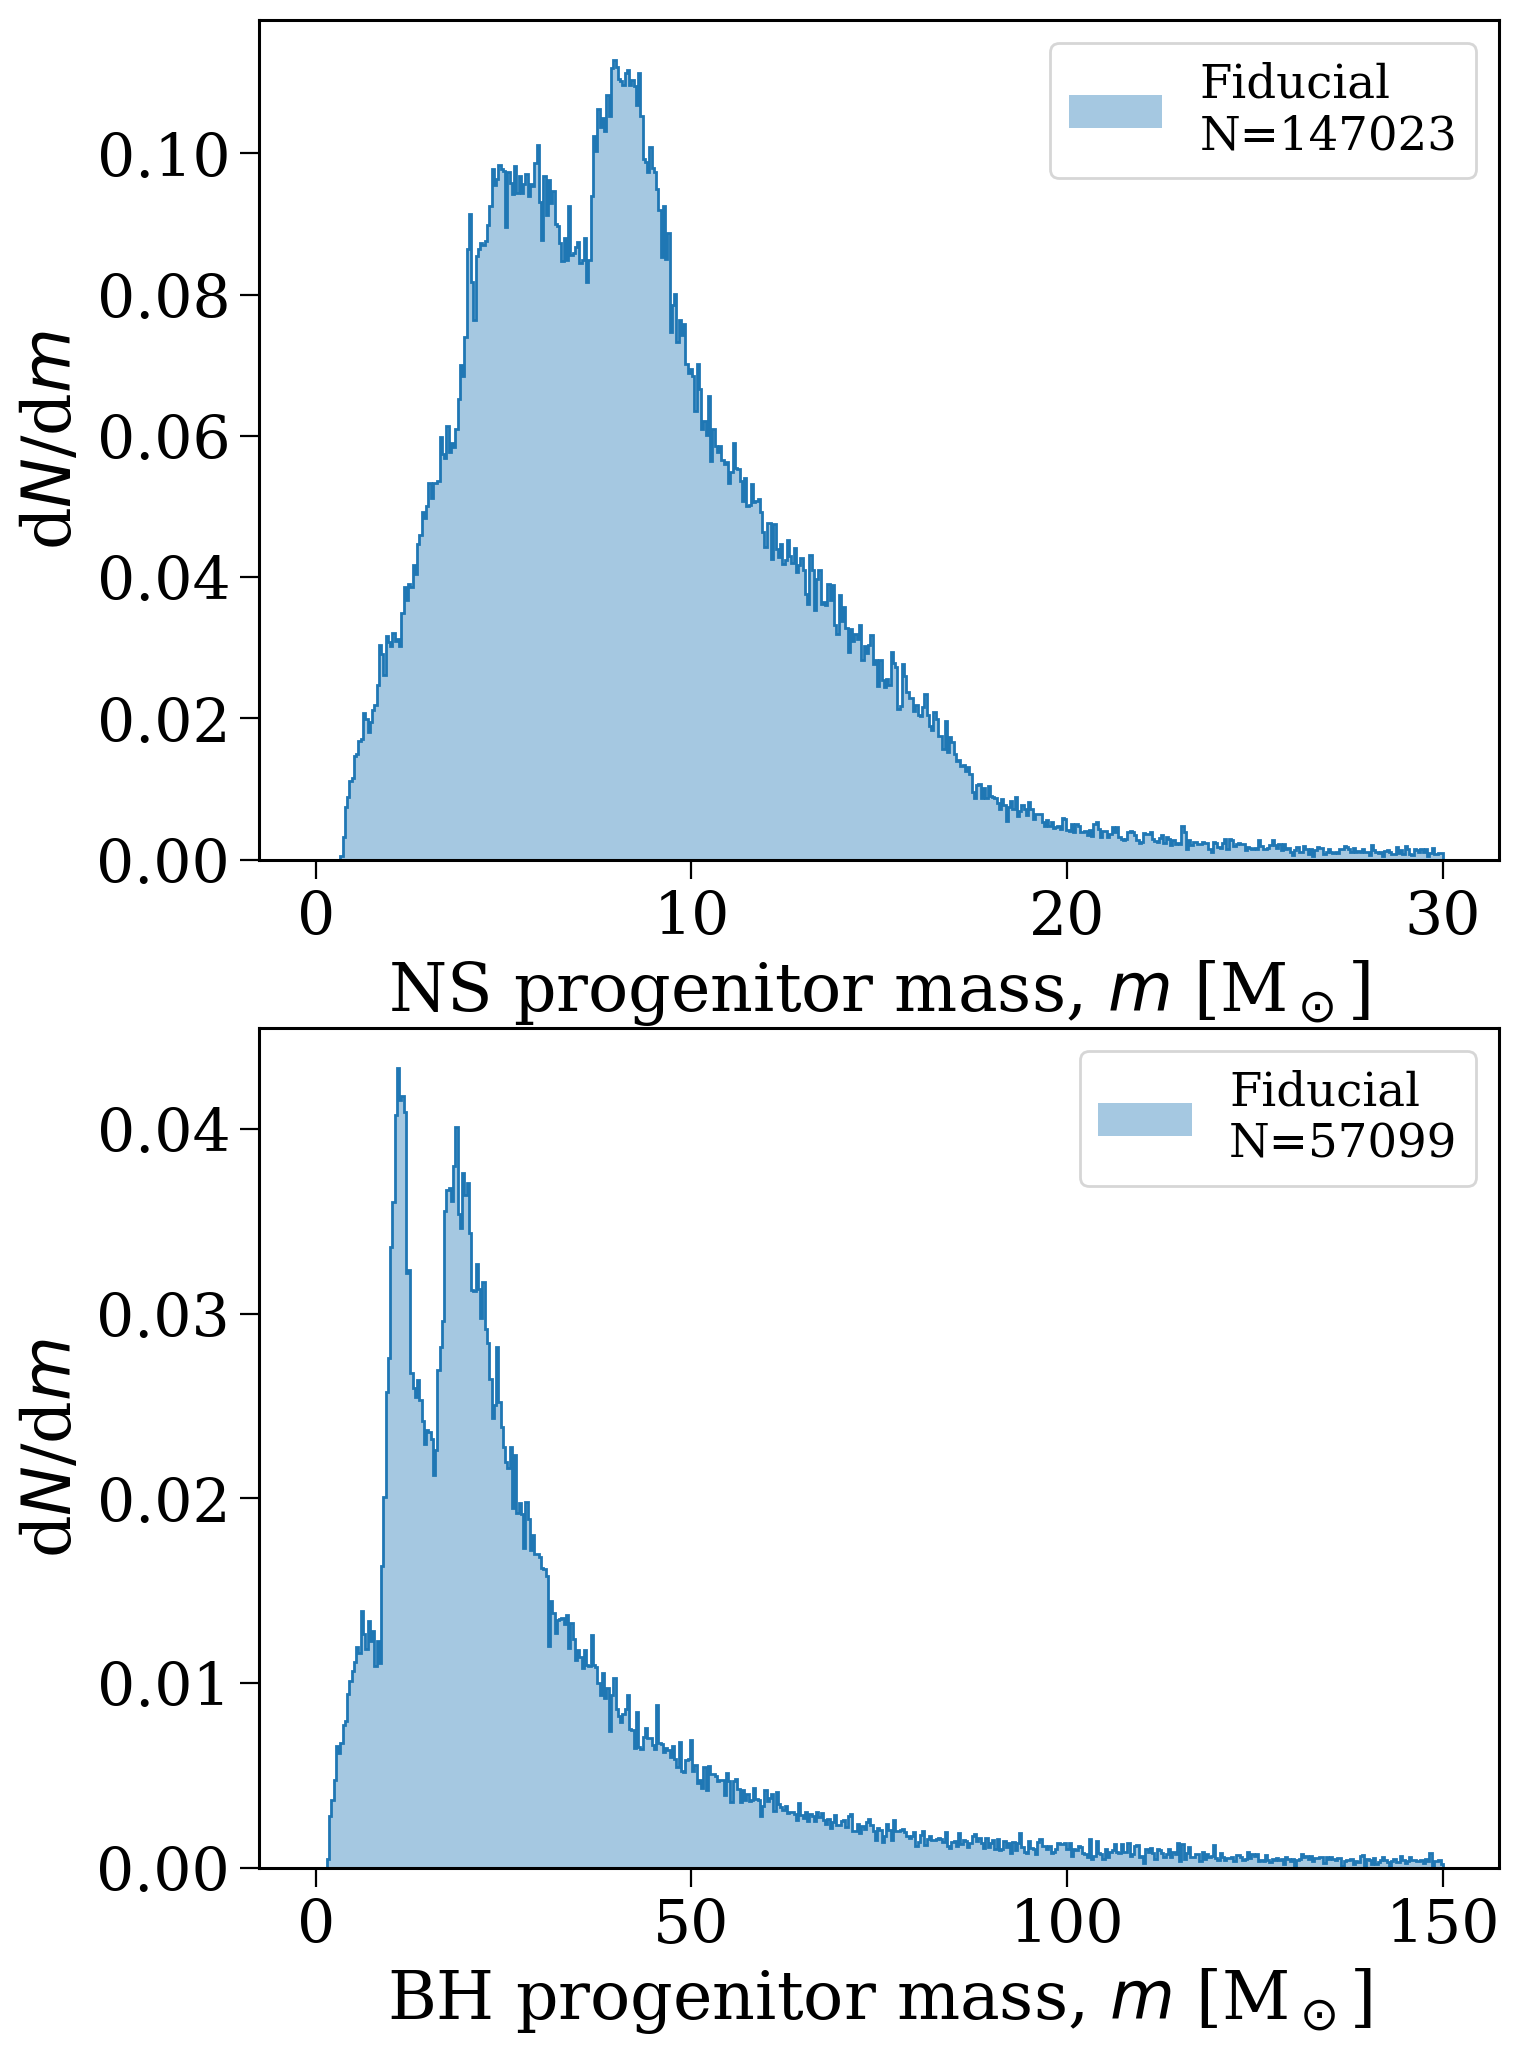

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(8, 12))

for ax, co_type, kstar, bins in zip(axes, ['NS', 'BH'], [13, 14],
                                    [np.linspace(0, 30, 501), np.linspace(0, 150, 501)]):
    plotting.compare_table_quantity(
        pops=[pop],
        table_name="initC",
        quantity="mass",
        kstar=kstar,
        bins=bins,
        xlabel=f"{co_type} progenitor mass, $m$ [M$_\odot$]",
        ylabel=f"d$N$/d$m$",
        density=True,
        ax=ax,
        fig=fig,
        show=False,
        lw=1
    )

plt.savefig("../plots/progenitor_masses.pdf", format="pdf", bbox_inches='tight')
plt.show()

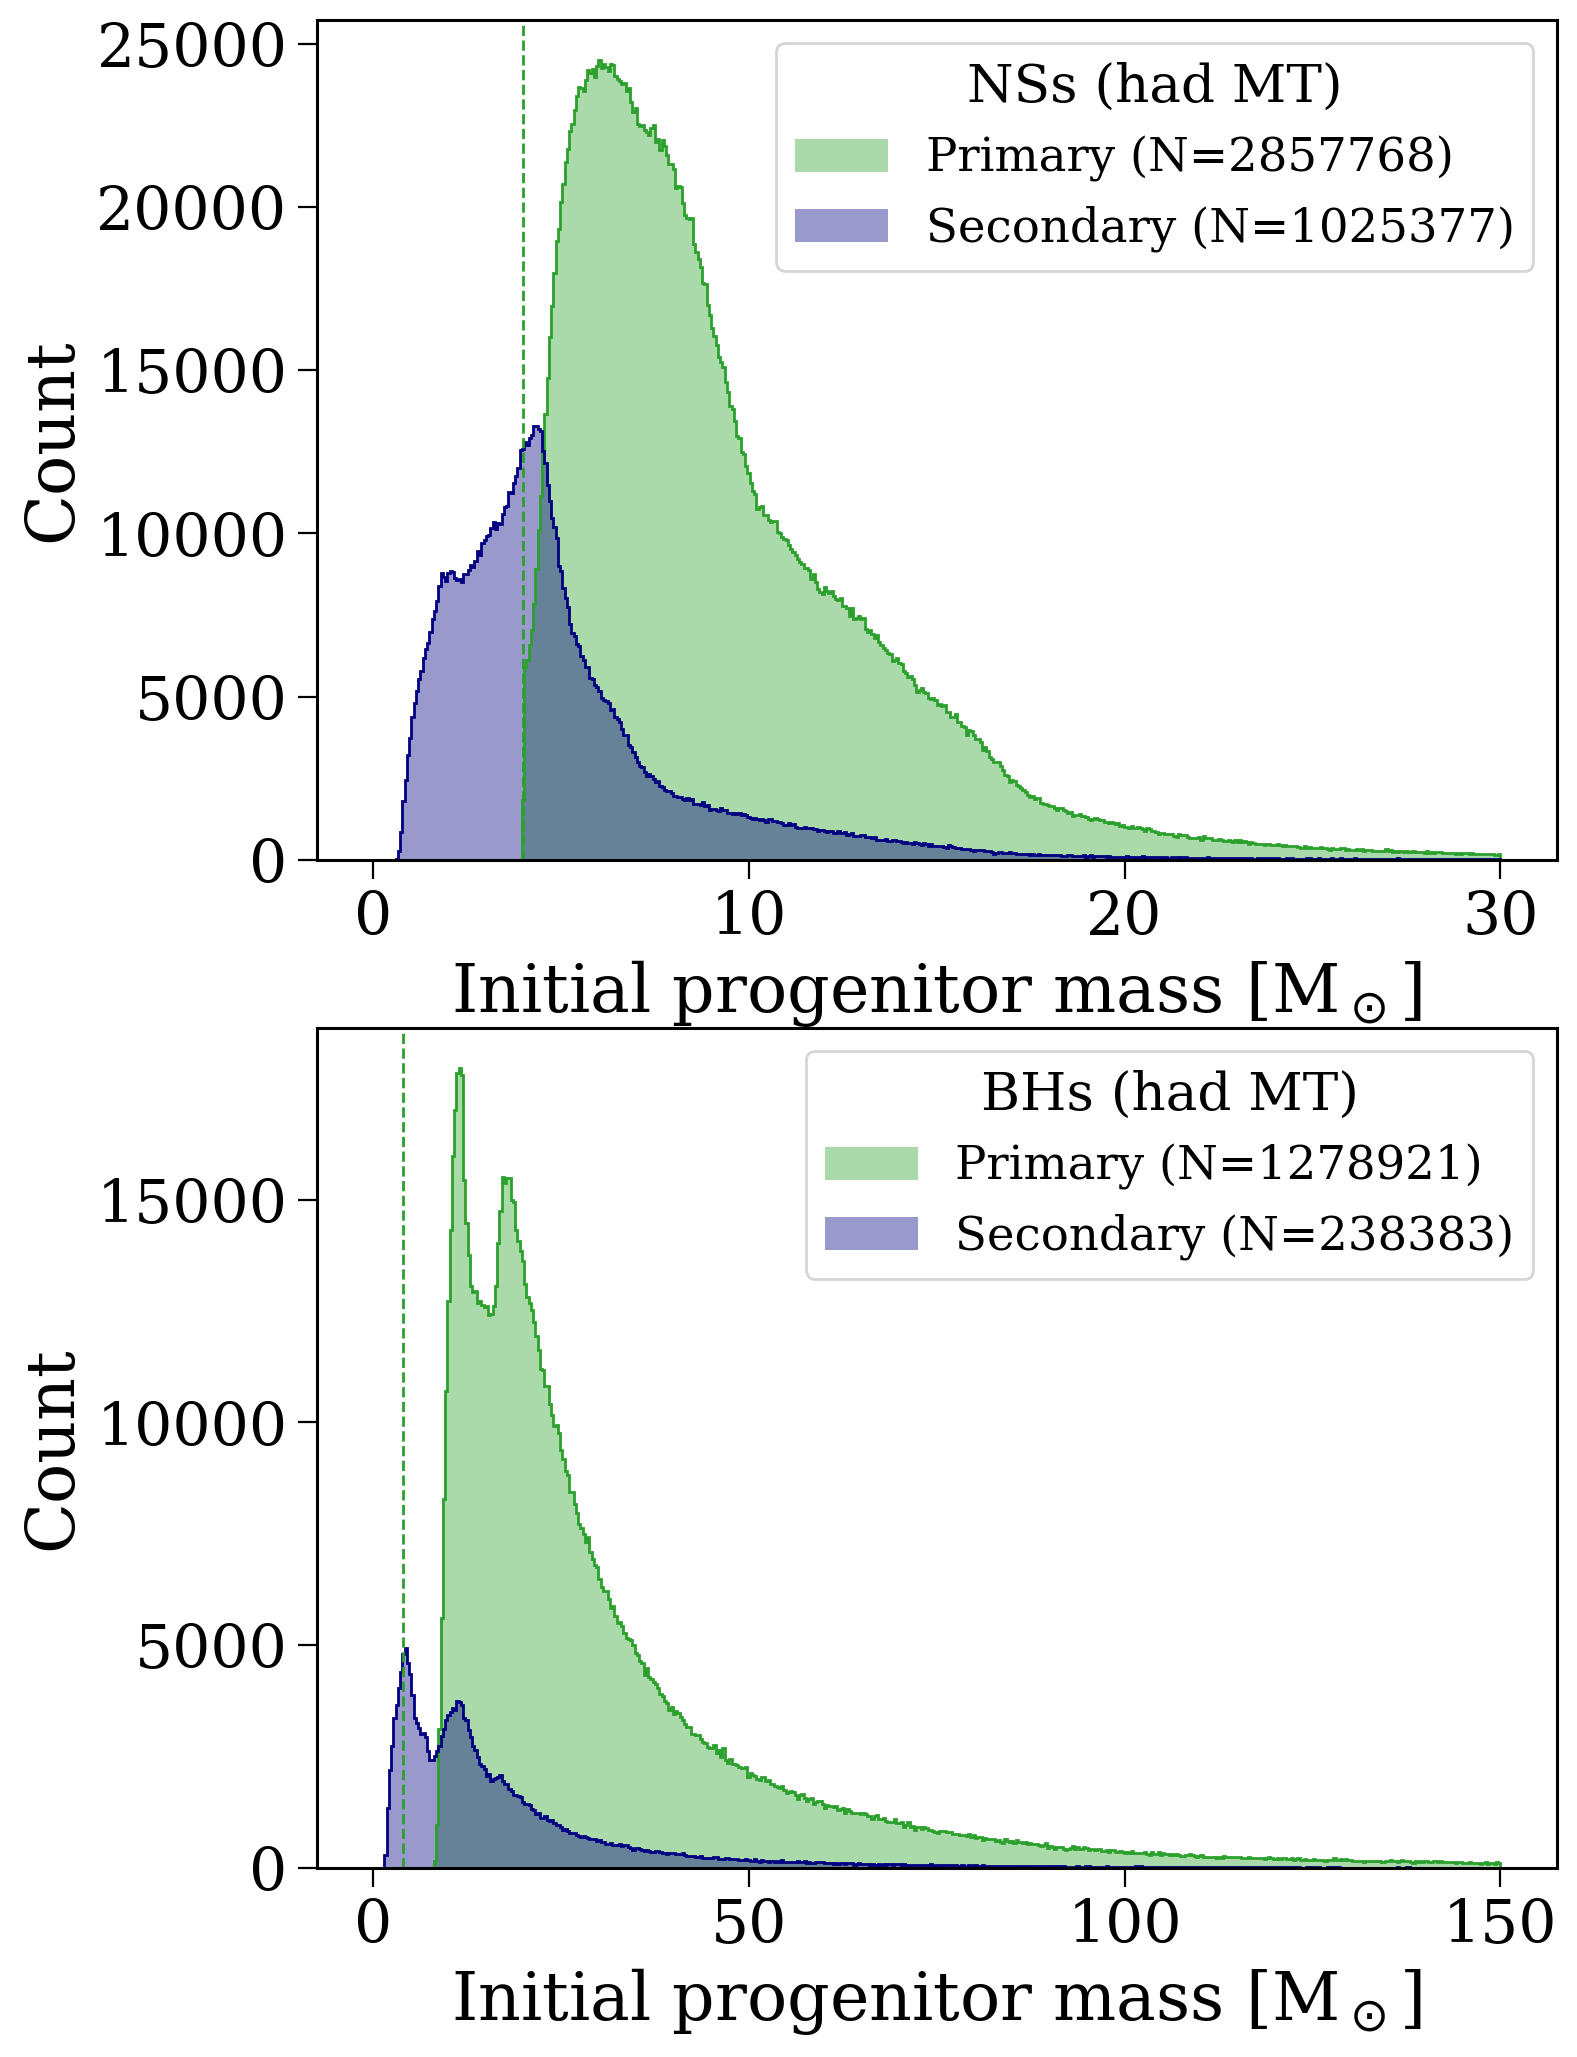

In [59]:
fig, axes = plt.subplots(2, 1, figsize=(8, 12))

for ax, co_type, kstar, bins in zip(axes, ['NS', 'BH'], [13, 14],
                                    [np.linspace(0, 30, 501), np.linspace(0, 150, 501)]):
    for comp, colour, label in zip(["1", "2"], ["tab:green", "navy"], ["Primary", "Secondary"]):
        experienced_mt = pop.bpp[pop.bpp["evol_type"] == 3]["bin_num"]
        experienced_ce = pop.bpp[pop.bpp["evol_type"] == 7]["bin_num"]

        init_masses = pop.initC[f"mass_{comp}"][(
            (pop.final_bpp[f"kstar_{comp}"] == kstar)
            & (pop.final_bpp["bin_num"].isin(experienced_mt))
            # & ~(pop.final_bpp["bin_num"].isin(experienced_ce))
        )]

        ax.hist(init_masses, bins=bins, histtype='step', lw=1, color=colour)
        ax.hist(init_masses, bins=bins, alpha=0.4, color=colour,
                label=f"{label} (N={len(init_masses)})")
        
    ax.axvline(4, color="tab:green", ls='--', lw=1)

    ax.set(
        xlabel=f"Initial progenitor mass [M$_\odot$]",
        ylabel="Count"
    )
    ax.legend(title=f"{co_type}s (had MT)")

plt.savefig("../plots/progenitor_masses_mt.pdf", format="pdf", bbox_inches='tight')
plt.show()

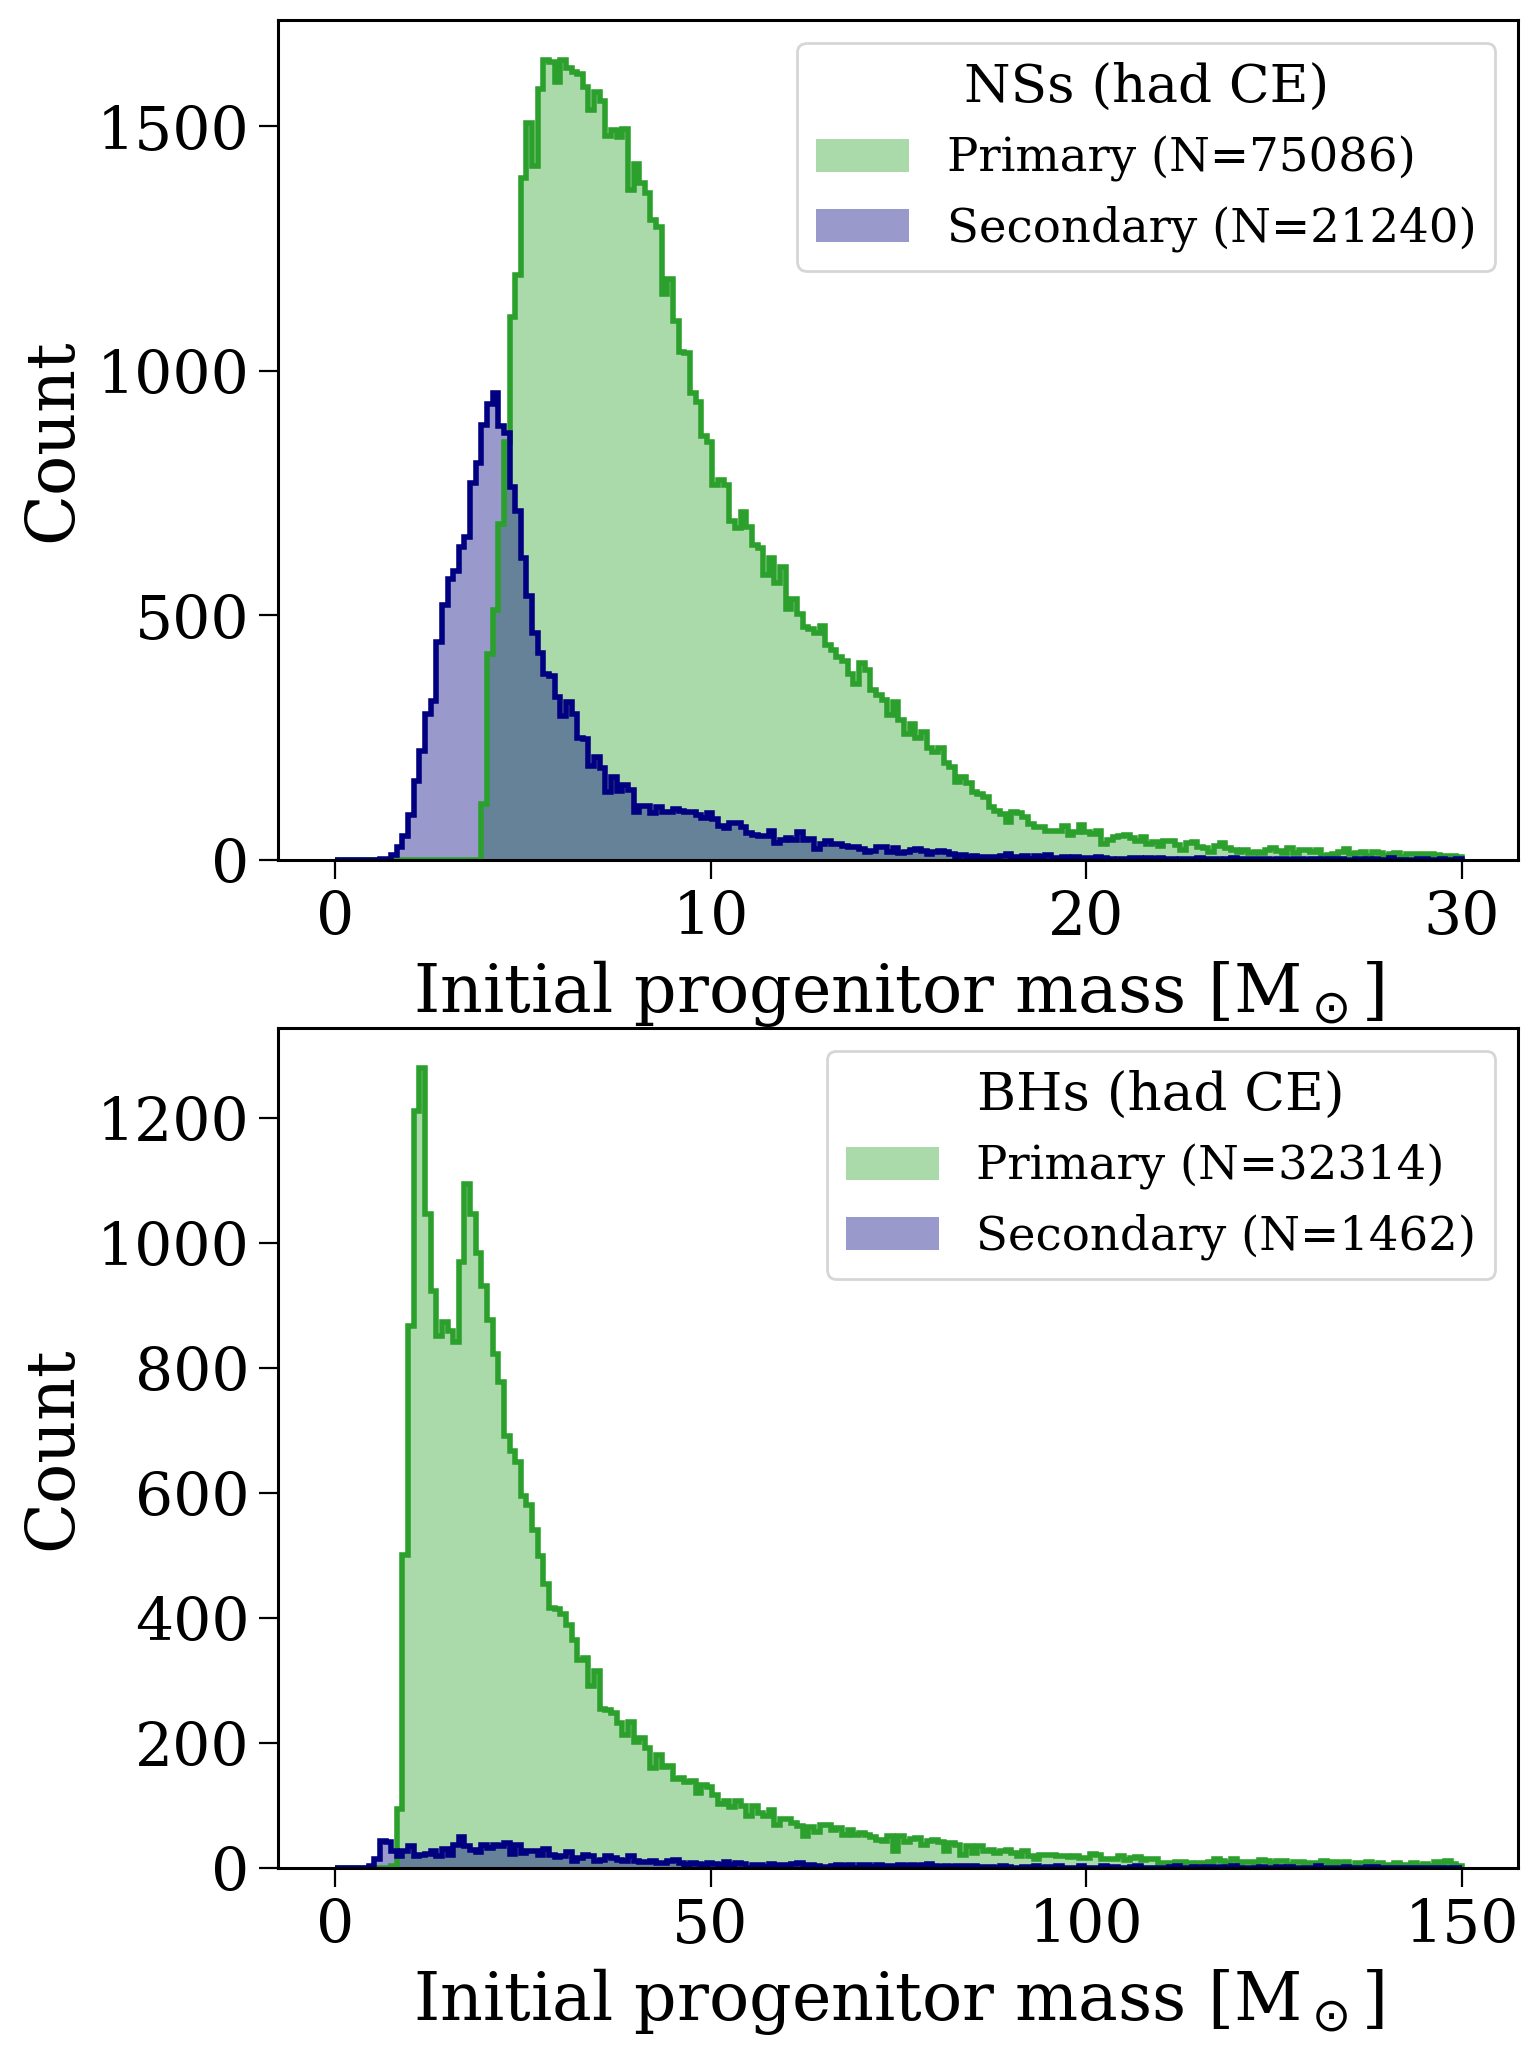

In [71]:
fig, axes = plt.subplots(2, 1, figsize=(8, 12))

for ax, co_type, kstar, bins in zip(axes, ['NS', 'BH'], [13, 14],
                                    [np.linspace(0, 30, 201), np.linspace(0, 150, 201)]):
    for comp, colour, label in zip(["1", "2"], ["tab:green", "navy"], ["Primary", "Secondary"]):
        experienced_mt = pop.bpp[pop.bpp["evol_type"] == 3]["bin_num"]
        experienced_ce = pop.bpp[pop.bpp["evol_type"] == 7]["bin_num"]

        init_masses = pop.initC[f"mass_{comp}"][(
            (pop.final_bpp[f"kstar_{comp}"] == kstar)
            & (pop.final_bpp["bin_num"].isin(experienced_mt))
            & (pop.final_bpp["bin_num"].isin(experienced_ce))
        )]

        ax.hist(init_masses, bins=bins, histtype='step', lw=2, color=colour)
        ax.hist(init_masses, bins=bins, alpha=0.4, color=colour,
                label=f"{label} (N={len(init_masses)})")

    ax.set(
        xlabel=f"Initial progenitor mass [M$_\odot$]",
        ylabel="Count"
    )
    ax.legend(title=f"{co_type}s (had CE)")

plt.savefig("../plots/progenitor_masses_ce.pdf", format="pdf", bbox_inches='tight')
plt.show()

In [ ]:
bh_bin_nums = np.concatenate((
    pop.final_bpp["bin_num"][pop.final_bpp["kstar_1"] == 14],
    pop.final_bpp["bin_num"][pop.final_bpp["kstar_2"] == 14]
))

In [ ]:
n_primary_bh = (pop.final_bpp["kstar_1"] == 14).sum()

In [ ]:
primary_escaped_bh_kicks = pop.kick_info.loc[bh_bin_nums[:n_primary_bh][kinematics["Fiducial"]["escaped"]["BH"][:n_primary_bh]]]
primary_escaped_bh_kick_mags = primary_escaped_bh_kicks[primary_escaped_bh_kicks["star"] == 1.0]["natal_kick"]

secondary_escaped_bh_kicks = pop.kick_info.loc[bh_bin_nums[n_primary_bh:][kinematics["Fiducial"]["escaped"]["BH"][n_primary_bh:]]]
secondary_escaped_bh_kick_mags = secondary_escaped_bh_kicks[secondary_escaped_bh_kicks["star"] == 2.0]["natal_kick"]

escaped_bh_kick_mags = pd.concat((primary_escaped_bh_kick_mags, secondary_escaped_bh_kick_mags))

primary_bh_kicks = pop.kick_info.loc[bh_bin_nums[:n_primary_bh]]
primary_bh_kick_mags = primary_bh_kicks[primary_bh_kicks["star"] == 1.0]["natal_kick"]
secondary_bh_kicks = pop.kick_info.loc[bh_bin_nums[n_primary_bh:]]
secondary_bh_kick_mags = secondary_bh_kicks[secondary_bh_kicks["star"] == 2.0]["natal_kick"]
bh_kick_mags = pd.concat((primary_bh_kick_mags, secondary_bh_kick_mags))

print(np.percentile(bh_kick_mags, [2.5, 16, 50, 84, 97.5]))
print(np.percentile(escaped_bh_kick_mags, [2.5, 16, 50, 84, 97.5]))

[  0.           7.78105342  95.92867689 248.00206943 538.54430135]
[ 332.69763805  419.67293693  585.74876478  867.75643026 1295.93369777]
